<img src="/home/jakubzig/cnn-digit-recognition-project/src/bilder/TH_Wildau_Logo.png" width="250" align="right"/>

# Convolutional Neural Network zur Ziffernerkennung
## Implementierung mit PyTorch am Beispiel MNIST



**Autor:** Christian Jakubzig  
**Version:** 1.0  
**Datum:** Februar 2026  
**Kurs:** Master of Science Library Informatics – TH Wildau



### Beschreibung
Dieses Notebook dokumentiert die schrittweise Implementierung 
eines CNN zur Erkennung handgeschriebener Ziffern (0–9).

## Inhaltsverzeichnis

0. [Framework Pytorch](#pytorch)
1. [Setup & Imports](#imports)\
1.1 [Verwendete Bibliotheken](#library)
2. [Datensatz laden](#data)\
2.1 [Transformationspipeline](#transform)\
2.2 [Trainingsdaten laden](#train)\
2.3 [Testdaten laden](#test)\
2.4 [Beispielbilder visualisieren](#beispielbilder)
3. [Gerät konfigurieren](#device)
4. [Modell-Architektur](#model)\
4.1 [Layer-Definitionen](#layer)\
4.2 [Forward Pass](#forward)\
4.3 [Modell initialisieren](#init)\
4.4 [Architektur visualisieren](#modelvisual)
5. [Loss & Optimizer](#loss)
6. [Training](#training)
7. [Test](#testing)
8. [Training ausführen](#execution)\
8.1 [Trainingsverlauf visualisieren](#executionvisuals)
9. [Ergebnisse visualisieren](#results)
10. [Reflexion](#reflexion)
11. [Quellen](#quellen)
12. [Abbildungsverzeichnis](#abbv)

## Framework: PyTorch <a id='pytorch'></a>

- Open-Source Framework für maschinelles Lernen (Meta AI)
- Neuronale Netze in Python definieren und trainieren
- Dynamische Berechnungsgraphen → einfaches Debugging
- In diesem Projekt: CNN zur Ziffernerkennung

## 1. Setup & Imports <a id='imports'></a>

In [21]:
# Kernbibliotheken
import torch
import torch.nn as nn
import torch.nn.functional as F

# Datenvorbereitung
from torchvision import datasets, transforms

# Training
import torch.optim as optim

# Hilfsmittel
import matplotlib.pyplot as plt
import numpy as np
from torchinfo import summary
from torchview import draw_graph
from sklearn.metrics import confusion_matrix

%matplotlib inline

### 1.1 Verwendete Bibliotheken <a id='library'></a>

**Kernbibliotheken:**
- `torch` – Tensoren, GPU-Beschleunigung [[1]](#quellen)
- `torch.nn` – Fertige Layer-Bausteine (Conv2d, Linear, ...) [[2]](#quellen)
- `torch.nn.functional` – Funktionen ohne lernbare Parameter (ReLU, MaxPool) [[3]](#quellen)

**Datenvorbereitung:**
- `torchvision.datasets` – Fertige Datensätze, u.a. MNIST [[4]](#quellen)
- `torchvision.transforms` – Bildvorverarbeitung (Tensor, Normalisierung) [[5]](#quellen)

**Training & Visualisierung:**
- `torch.optim` – Optimierungsalgorithmen [[6]](#quellen)
- `matplotlib`, `torchinfo`, `torchview`, `sklearn` – Visualisierung

## 2. Datensatz laden <a id='data'></a>

**MNIST** (Modified National Institute of Standards and Technology) [[7]](#quellen)
- Erstellt 1998 von Yann LeCun et al.
- Benchmark-Datensatz zum Testen von Algorithmen zur Bilderkennung
- 70.000 handgeschriebene Ziffern (0–9) · 28×28 Pixel · Graustufen
- 60.000 Trainingsbilder · 10.000 Testbilder
- Frei verfügbar · wird direkt über `torchvision` geladen

### 2.1 Transformationspipeline <a id='transform'></a>

- `ToTensor()` – Bilder → Tensoren
- `Normalize()` – Pixelwerte normalisieren


In [22]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

### 2.2 Trainingsdaten laden <a id='train'></a>

- `batch_size=64` – Wieviele Bilder gleichzeitig verarbeitet werden
- `shuffle=True` – Daten werden in zufälliger Reihenfolge geladen (verhindert Auswendiglernen von Mustern)
- `num_workers=1` – Anzahl CPU-Prozesse die Daten im Hintergrund laden
- `pin_memory=True` – Beschleunigt den Transfer CPU→GPU

In [23]:
train_data = torch.utils.data.DataLoader(
    datasets.MNIST('data', train=True, download=True, transform=transform),
    batch_size=64,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
)

### 2.3 Testdaten laden <a id='test'></a>

Wichtige Unterschiede:
- `train=False` – Lädt die 10.000 Testbilder
- `shuffle=False` – Keine Zufallsreihenfolge (für reproduzierbare Ergebnisse)

In [24]:
test_data = torch.utils.data.DataLoader(
    datasets.MNIST('data', train=False, download=True, transform=transform),
    batch_size=64,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
)

### 2.4 Beispielbilder visualisieren <a id='beispielbilder'></a>

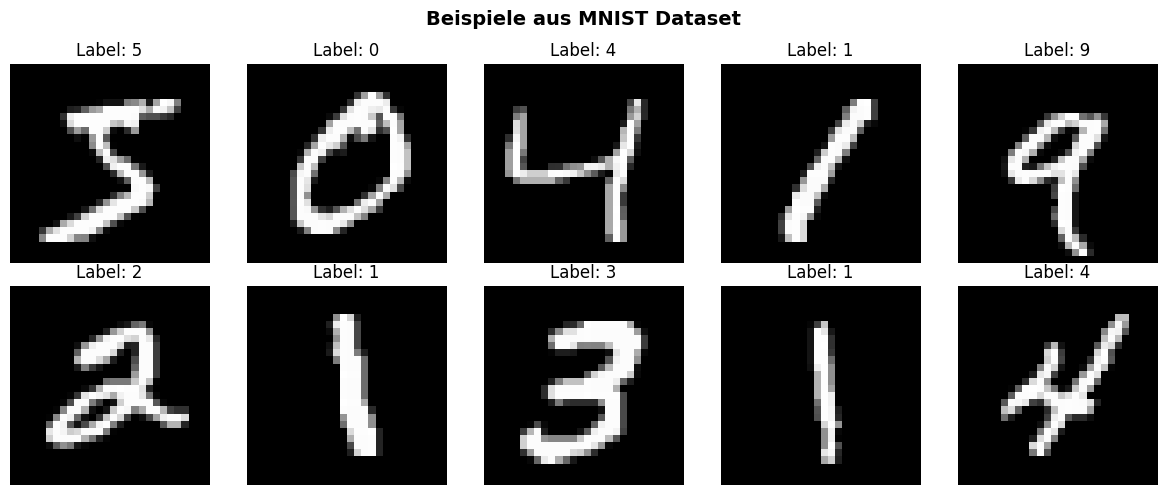

Training: 60000 Bilder
Test: 10000 Bilder
Batch Size: 64


In [41]:
# Schauen wir uns ein paar MNIST Bilder an
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    # Ein Bild aus dem Dataset holen
    img, label = train_data.dataset[i]
    
    # Von Tensor zu NumPy für Matplotlib
    img_np = img.squeeze().numpy()
    
    ax.imshow(img_np, cmap='gray')
    ax.set_title(f'Label: {label}', fontsize=12)
    ax.axis('off')

plt.suptitle('Beispiele aus MNIST Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Training: {len(train_data.dataset)} Bilder")
print(f"Test: {len(test_data.dataset)} Bilder")
print("Batch Size: 64")

## 3. Device konfigurieren <a id='device'></a>

GPU nutzen falls verfügbar, sonst CPU.

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Verwende: {device}')

Verwende: cuda


## 4. Modell-Architektur <a id='model'></a>

### 4.1 Layer-Definitionen (`__init__`) <a id='layer'></a>

Hier definieren wir die Architektur unseres Netzes - welche Layer existieren und welche Parameter sie haben.

**Convolutional Layers (Feature Extraction):**
- `conv1`: Erster Conv-Layer mit 1 Input-Kanal (Graustufenbild) und 10 Output-Kanälen (Feature Maps). Verwendet einen 5×5 Filter.
- `conv2`: Zweiter Conv-Layer verarbeitet die 10 Feature Maps von conv1 und erzeugt 20 neue Feature Maps mit einem 5×5 Filter.
- `Dropout2d`: Schaltet zufällig Neuronen während des Trainings aus um Overfitting zu verhindern.

**Fully Connected Layers (Klassifikation):**
- `fc1`: Erster FC-Layer verdichtet die 320 Features (20×4×4 nach den Conv-Layern) auf 60 Neuronen.
- `fc2`: Ausgabe-Layer mit 10 Neuronen - eines für jede Ziffer (0-9).

### 4.2 Forward Pass (`forward()`) <a id='forward'></a>

Der Forward Pass zeigt wie die Daten durch das Netz fließen:

**Feature Extraction (Convolutional Teil):**
1. Conv1 + MaxPool + ReLU → Erste Features extrahieren
2. Conv2 + Dropout + MaxPool + ReLU → Komplexere Features lernen

**Klassifikation (Fully Connected Teil):**

3. Flatten → 3D-Tensor (4×4×20) wird zu 1D-Vektor (320)
4. FC1 + ReLU → Feature-Verdichtung
5. FC2 → Ausgabe (10 Ziffern)


In [27]:
class Netz(nn.Module):
    def __init__(self):
        super(Netz, self).__init__()
        self.convl = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conf_dropout = nn.Dropout2d()
        self.fcl1 = nn.Linear(320, 60)
        self.fcl2 = nn.Linear(60, 10)

    def forward(self, x):
        x = self.convl(x)
        x = F.max_pool2d(x, 2)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.conf_dropout(x)
        x = F.max_pool2d(x, 2)
        x = F.relu(x)
        x = x.view(-1, 320)
        x = F.relu(self.fcl1(x))
        x = self.fcl2(x)
        return x

### 4.3 Modell initialisieren <a id='init'></a>

In [28]:
model = Netz().to(device)
print(model)

Netz(
  (convl): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (conf_dropout): Dropout2d(p=0.5, inplace=False)
  (fcl1): Linear(in_features=320, out_features=60, bias=True)
  (fcl2): Linear(in_features=60, out_features=10, bias=True)
)


### 4.4 Architektur visualisieren <a id='modelvisual'></a>

Zunächst eine sehr anschauliche Visualisierung eines sehr ähnlichen Netzes: https://adamharley.com/nn_vis/cnn/3d.html [[8]](#quellen)

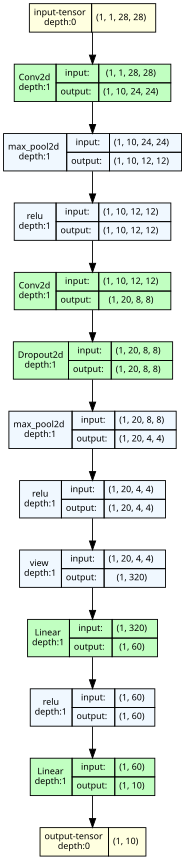

In [29]:
model_graph = draw_graph(
    model, 
    input_size=(1, 1, 28, 28),
    expand_nested=True,
    graph_name='CNN Architecture'
)
model_graph.visual_graph

## 5. Loss & Optimizer <a id='loss'></a>

### Loss Function

**CrossEntropyLoss** misst wie stark die Vorhersage vom richtigen 
Ergebnis abweicht. Kombiniert Softmax und Negative Log-Likelihood.

### Optimizer

**SGD (Stochastic Gradient Descent)** passt die Gewichte an um den 
Loss zu minimieren.

- `lr=0.1` – Lernrate (Schrittgröße)
- `momentum=0.8` – Beschleunigt Konvergenz

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.8)

## 6. Training <a id='training'></a>

Die Trainingsschleife führt für jeden Batch folgende Schritte aus:
1. Forward Pass - Daten durchs Netz
2. Loss berechnen - Fehler messen
3. Backward Pass - Gradienten berechnen
4. Gewichte aktualisieren

In [31]:
def train(epoch):
    model.train()
    total_loss = 0

    for batch_id, (data, target) in enumerate(train_data):
        data = data.to(device) # Daten auf die GPU laden
        target = target.to(device) # Labels auf die GPU laden
        
        optimizer.zero_grad() # Alte Gradienten löschen
        out = model(data) # Forward Pass - Vorhersage machen
        loss = criterion(out, target) # Loss berechnen (wie falsch?)
        loss.backward() # Backward Pass - Gradienten berechnen
        optimizer.step() # Gewichte anpassen

        total_loss += loss.item()
        
        if batch_id % 100 == 0:
            print(
                "Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}".format(
                    epoch,
                    batch_id * len(data),
                    len(train_data.dataset),
                    100.0 * batch_id / len(train_data),
                    loss.item(),
                )
            )

    return total_loss / len(train_data)

## 7. Test <a id='testing'></a>

Nach jeder Trainings-Epoche evaluieren wir das Modell auf den Testdaten 
um die Genauigkeit zu messen. Im Test-Modus ist Dropout deaktiviert und 
es werden keine Gradienten berechnet.

In [32]:
def test():
    model.eval() #Test-Modus, dropout ausgeschaltet
    loss = 0
    correct = 0
    
    with torch.no_grad(): # Keine Gradienten berechnen
        for data, target in test_data:
            data = data.to(device)
            target = target.to(device)

            out = model(data)
            loss += F.cross_entropy(out, target, reduction='sum').item() # Berechnet loss für aktelles Batch

            prediction = out.data.max(1, keepdim=True)[1]
            correct += prediction.eq(target.data.view_as(prediction)).cpu().sum()
            
    loss = loss / len(test_data.dataset)
    accuracy = 100.0 * correct / len(test_data.dataset)

    print("Durchschnittsloss: ", loss)
    print(f"Genauigkeit: {accuracy:.2f}%")

    return loss, accuracy

## 8. Training ausführen <a id='execution'></a>

Das Training läuft über 9 Epochen. In jeder Epoche:
1. `train(epoch)` - Das Modell lernt aus den 60.000 Trainingsbildern
2. `test()` - Wir messen die Genauigkeit auf den 10.000 Testbildern

In [33]:
# Listen zum Speichern der Metriken
train_losses = []
test_losses = []
test_accuracies = []

In [34]:
for epoch in range(1, 10):
    train_loss = train(epoch)
    test_loss, test_acc = test()

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.303985
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.322875
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.261951
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.492021
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.279747
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.276905
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.377208
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.260654
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.454271
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.393870
Durchschnittsloss:  0.10408007254451514
Genauigkeit: 96.87%
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.166098
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.302446
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.277171
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.312540
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.380890
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.216294
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.238834
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.300270
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.071837
Tr

### 8.1 Trainingsverlauf visualisieren <a id='executionvisuals'></a>


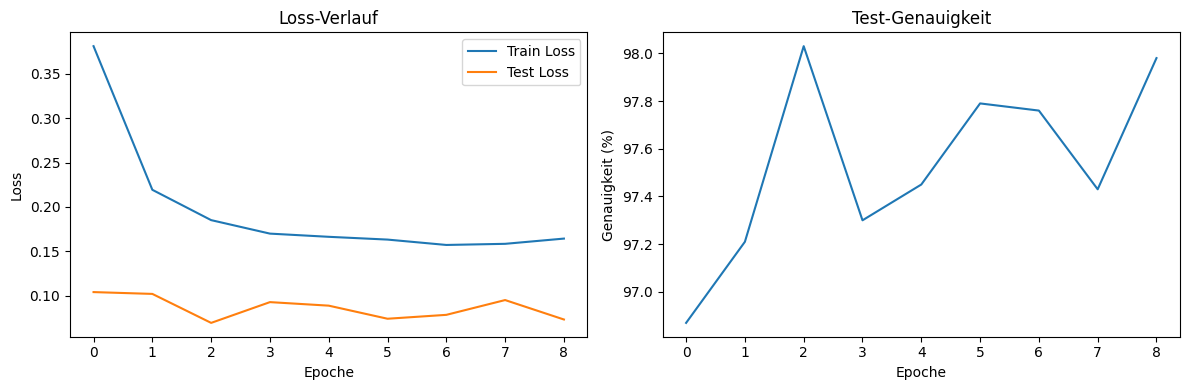

In [35]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss-Verlauf')

plt.subplot(1, 2, 2)
plt.plot(test_accuracies)
plt.xlabel('Epoche')
plt.ylabel('Genauigkeit (%)')
plt.title('Test-Genauigkeit')

plt.tight_layout()
plt.show()

## 9. Ergebnisse visualisieren <a id='results'></a>

### 9.1 Zufällige Testbilder

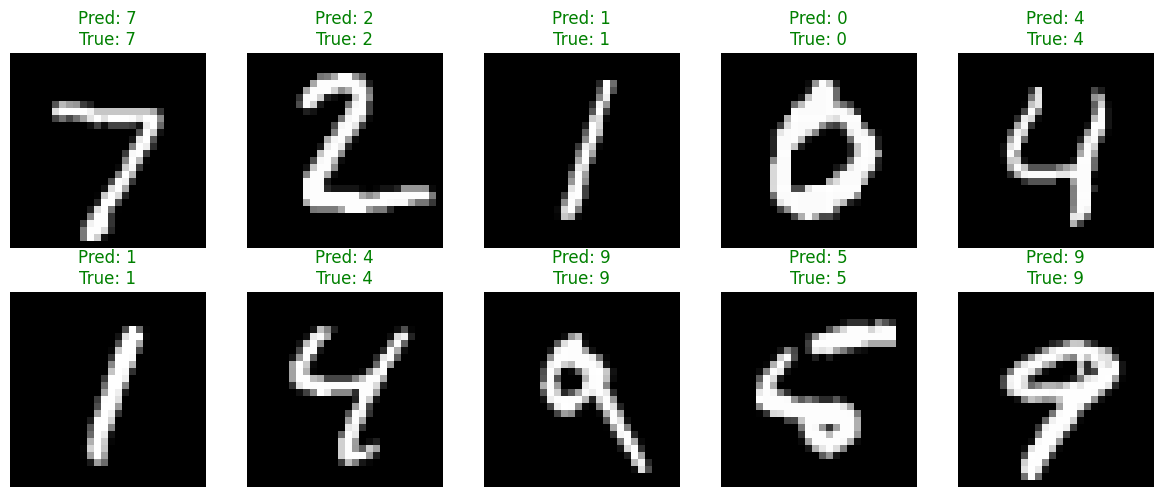

In [36]:
# 10 zufällige Testbilder laden
model.eval()
examples = iter(test_data)
example_data, example_targets = next(examples)

with torch.no_grad():
    example_data = example_data.to(device)
    output = model(example_data)
    predictions = output.max(1, keepdim=True)[1]

# Visualisieren
fig = plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(example_data[i][0].cpu(), cmap='gray')
    
    pred = predictions[i].item()
    true = example_targets[i].item()
    color = 'green' if pred == true else 'red'
    
    plt.title(f'Pred: {pred}\nTrue: {true}', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 9.2 Fehlerbilder

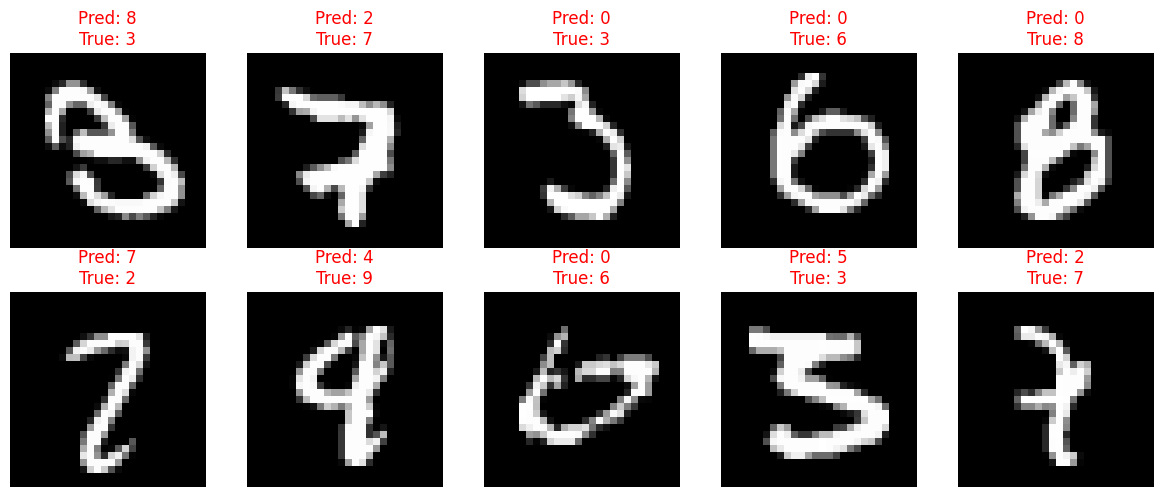

In [37]:
# Alle Testbilder durchgehen und falsche Vorhersagen sammeln
model.eval()
incorrect_examples = []
incorrect_preds = []
incorrect_targets = []

with torch.no_grad():
    for data, target in test_data:
        data = data.to(device)
        target = target.to(device)  # ← AUCH auf GPU!
        output = model(data)
        pred = output.max(1, keepdim=True)[1].squeeze()
        
        # Nur falsche Vorhersagen speichern
        mask = pred != target
        incorrect_examples.extend(data[mask].cpu())
        incorrect_preds.extend(pred[mask].cpu())
        incorrect_targets.extend(target[mask].cpu())  # ← .cpu() hinzufügen
        
        # Stoppen wenn wir 10 Fehler haben
        if len(incorrect_examples) >= 10:
            break

# Visualisieren (nur erste 10)
fig = plt.figure(figsize=(12, 5))
for i in range(min(10, len(incorrect_examples))):
    plt.subplot(2, 5, i+1)
    plt.imshow(incorrect_examples[i][0], cmap='gray')
    
    pred = incorrect_preds[i].item()
    true = incorrect_targets[i].item()
    
    plt.title(f'Pred: {pred}\nTrue: {true}', color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

### 9.3 Filter visualisierung

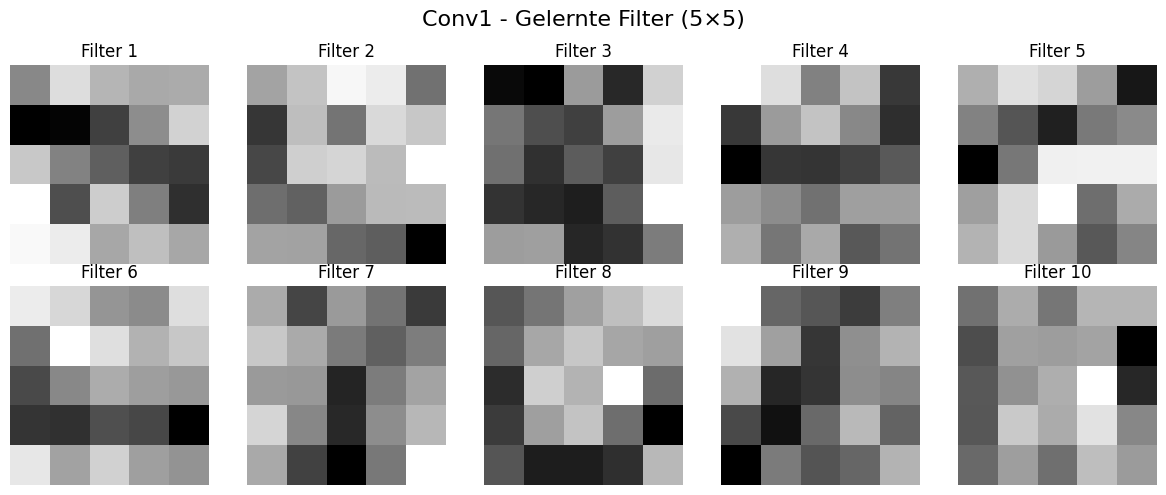

In [38]:
# Filter von Conv1 visualisieren (10 Filter 5x5)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Conv1 - Gelernte Filter (5×5)', fontsize=16)

for i, ax in enumerate(axes.flat):
    # Filter extrahieren und auf CPU holen
    filter_weights = model.convl.weight[i, 0].detach().cpu()
    
    # Visualisieren
    ax.imshow(filter_weights, cmap='gray')
    ax.set_title(f'Filter {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

### 9.4 Feature Maps – Was sieht das Netz nach Conv1?

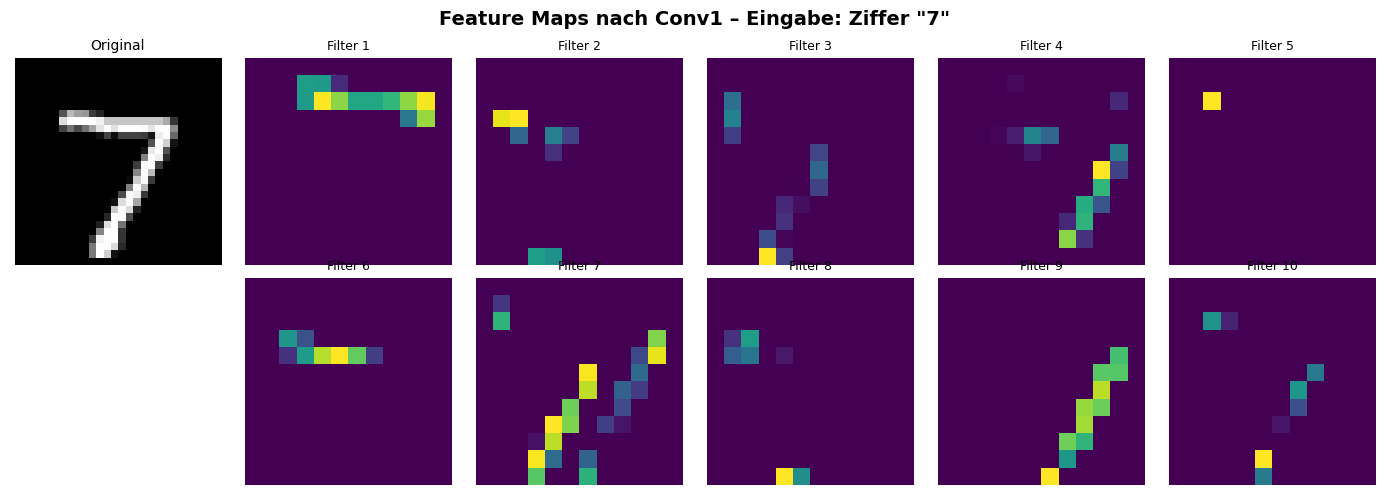

Jeder Filter reagiert auf andere Muster im Bild (Kanten, Kurven, ...)


In [39]:
# Ein Testbild durch Conv1 schicken und die 10 Feature Maps visualisieren
model.eval()

# Erstes Testbild holen
img, label = test_data.dataset[0]
img_tensor = img.unsqueeze(0).to(device)  # (1, 1, 28, 28)

# Nur bis nach Conv1 + ReLU + MaxPool rechnen
with torch.no_grad():
    x = model.convl(img_tensor)
    x = F.max_pool2d(x, 2)
    x = F.relu(x)  # Shape: (1, 10, 12, 12)

feature_maps = x.squeeze(0).cpu()  # (10, 12, 12)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle(f'Feature Maps nach Conv1 – Eingabe: Ziffer "{label}"', fontsize=14, fontweight='bold')

# Originalbild links
axes[0, 0].imshow(img.squeeze().numpy(), cmap='gray')
axes[0, 0].set_title('Original', fontsize=10)
axes[0, 0].axis('off')
axes[1, 0].axis('off')

# 10 Feature Maps
for i in range(10):
    row, col = divmod(i, 5)
    ax = axes[row, col + 1]
    ax.imshow(feature_maps[i].numpy(), cmap='viridis')
    ax.set_title(f'Filter {i+1}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("Jeder Filter reagiert auf andere Muster im Bild (Kanten, Kurven, ...)")

### 9.5 Confusion Matrix – Wo verwechselt das Netz Ziffern?

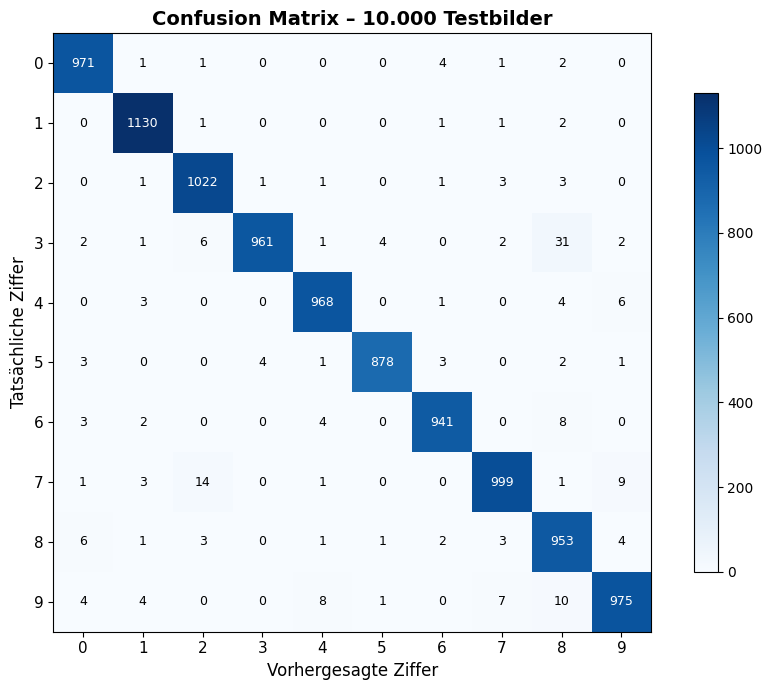

Häufigste Verwechslungen:
  Ziffer 3 → fälschlicherweise 8: 31x
  Ziffer 7 → fälschlicherweise 2: 14x
  Ziffer 9 → fälschlicherweise 8: 10x
  Ziffer 7 → fälschlicherweise 9: 9x
  Ziffer 6 → fälschlicherweise 8: 8x


In [ ]:

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_data:
        data = data.to(device)
        output = model(data)
        pred = output.max(1)[1].cpu().numpy()
        all_preds.extend(pred)
        all_targets.extend(target.numpy())

cm = confusion_matrix(all_targets, all_preds)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10), fontsize=11)
ax.set_yticklabels(range(10), fontsize=11)
ax.set_xlabel('Vorhergesagte Ziffer', fontsize=12)
ax.set_ylabel('Tatsächliche Ziffer', fontsize=12)
ax.set_title('Confusion Matrix – 10.000 Testbilder', fontsize=14, fontweight='bold')

# Werte in die Zellen schreiben
for i in range(10):
    for j in range(10):
        val = cm[i, j]
        color = 'white' if val > cm.max() / 2 else 'black'
        ax.text(j, i, str(val), ha='center', va='center', fontsize=9, color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# Häufigste Verwechslungen ausgeben
print("Häufigste Verwechslungen:")
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
for _ in range(5):
    idx = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
    print(f"  Ziffer {idx[0]} → fälschlicherweise {idx[1]}: {cm_no_diag[idx]}x")
    cm_no_diag[idx] = 0

## 10. Probleme & Reflexion

Die größte Herausforderung war nicht die technische Implementierung, 
sondern die Entscheidungsfindung zu Beginn des Projekts: Die Fülle 
an Möglichkeiten – welches Framework, welche Architektur, welches 
Design – führte zu einem anhaltenden Zweifel, ob eine andere Wahl 
nicht doch besser gewesen wäre.

In der Praxis hat sich gezeigt: Die gewählte Architektur erreicht 
~99% Genauigkeit auf den Testdaten. Das zeigt, dass es bei bekannten 
Problemen wie MNIST oft wichtiger ist, eine Entscheidung zu treffen 
und durchzuziehen, als die "perfekte" Lösung zu suchen.

## Quellen <a id='quellen'></a>

[1] PyTorch (2025). *torch*. https://pytorch.org/docs/stable/torch.html (letzter Zugriff 17.02.2025)

[2] PyTorch (2025). *torch.nn*. https://docs.pytorch.org/docs/stable/nn.html (letzter Zugriff 17.02.2025)

[3] PyTorch (2025). *torch.nn.functional*. https://docs.pytorch.org/docs/stable/nn.functional.html (letzter Zugriff 17.02.2025)

[4] PyTorch (2017). *torchvision.datasets*. https://docs.pytorch.org/vision/stable/datasets.html (letzter Zugriff 17.02.2025)

[5] PyTorch (2017). *torchvision.transforms*. https://docs.pytorch.org/vision/0.8/transforms.html (letzter Zugriff 17.02.2025)

[6] PyTorch (2025). *torch.optim*. https://docs.pytorch.org/docs/stable/optim.html (letzter Zugriff 17.02.2025)

[7] Wikipedia (2022). *MNIST-Datenbank*. https://de.wikipedia.org/wiki/MNIST-Datenbank (letzter Zugriff 17.02.2025)

[8] Harley, A. (2015). An Interactive Node-Link Visualization of Convolutional Neural Networks. https://adamharley.com/nn_vis/cnn/3d.html (letzter Zugriff: 23.02.2026)


## Abbildungsverzeichnis
Alle Abbildungen sind eigene Darstellungen, erstellt mit Matplotlib auf Basis des MNIST-Datensatzes (LeCun et al., 1998).